In [4]:
import numpy as np
from scipy.stats import norm

# Parameters
S0 = 100       # initial price
K = 105        # strike
T = 1          # time to maturity
r = 0.05       # risk-free rate
sigma = 0.2    # volatility
n_sims = 100000

# Monte Carlo simulation (Black-Scholes GBM dynamics)
np.random.seed(42)
Z = np.random.standard_normal(n_sims)
ST = S0 * np.exp((r - 0.5 * sigma**2)*T + sigma*np.sqrt(T)*Z)
mc_payoffs = np.maximum(ST - K, 0)
mc_price = np.exp(-r*T) * np.mean(mc_payoffs)

# Closed-form Black-Scholes
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

print("Monte Carlo price:", mc_price)
print("Black-Scholes price:", bs_price)


Monte Carlo price: 8.041620675135178
Black-Scholes price: 8.021352235143176


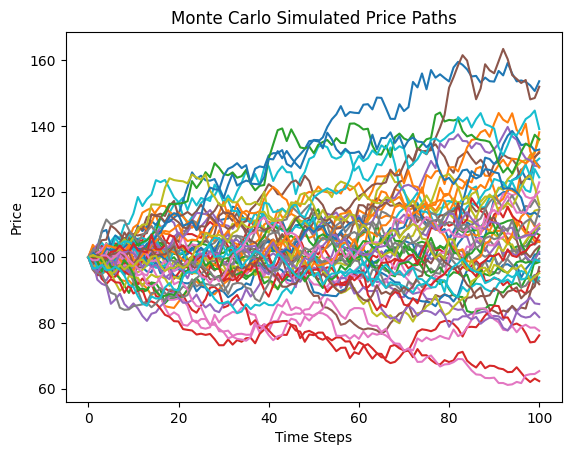

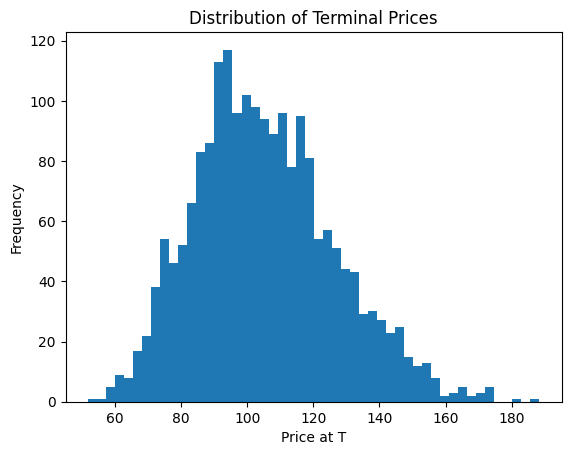

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 105
T = 1
r = 0.05
sigma = 0.2
n_sims = 2000
steps = 100

# Simulate GBM paths
dt = T/steps
paths = np.zeros((steps+1, n_sims))
paths[0] = S0

np.random.seed(42)
for t in range(1, steps+1):
    Z = np.random.standard_normal(n_sims)
    paths[t] = paths[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

# Plot sample paths
plt.figure()
for i in range(50):
    plt.plot(paths[:, i])
plt.title("Monte Carlo Simulated Price Paths")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()

# Plot terminal price distribution
ST = paths[-1]
plt.figure()
plt.hist(ST, bins=50)
plt.title("Distribution of Terminal Prices")
plt.xlabel("Price at T")
plt.ylabel("Frequency")
plt.show()


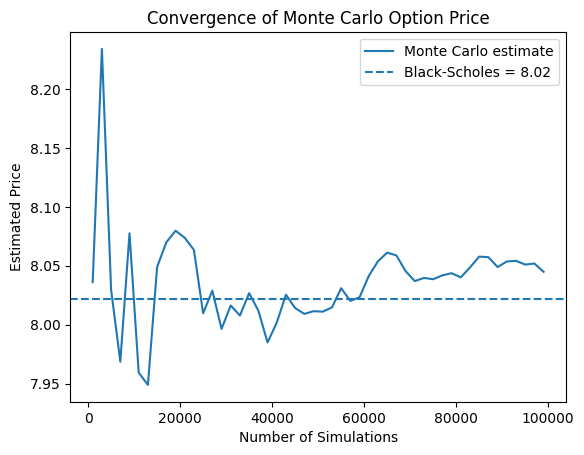

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 105
T = 1
r = 0.05
sigma = 0.2
n_sims = 100000

# Black-Scholes closed-form price
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_price = S0 * norm.cdf(d1) - K*np.exp(-r*T) * norm.cdf(d2)

# Monte Carlo simulation
np.random.seed(42)
Z = np.random.standard_normal(n_sims)
ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoffs = np.maximum(ST - K, 0)
discounted = np.exp(-r*T) * payoffs

# Convergence
convergence = []
sizes = range(1000, n_sims+1, 2000)
for size in sizes:
    convergence.append(np.mean(discounted[:size]))

# Plot
plt.figure()
plt.plot(sizes, convergence, label="Monte Carlo estimate")
plt.axhline(bs_price, linestyle='--', label=f"Black-Scholes = {bs_price:.2f}")
plt.title("Convergence of Monte Carlo Option Price")
plt.xlabel("Number of Simulations")
plt.ylabel("Estimated Price")
plt.legend()
plt.show()


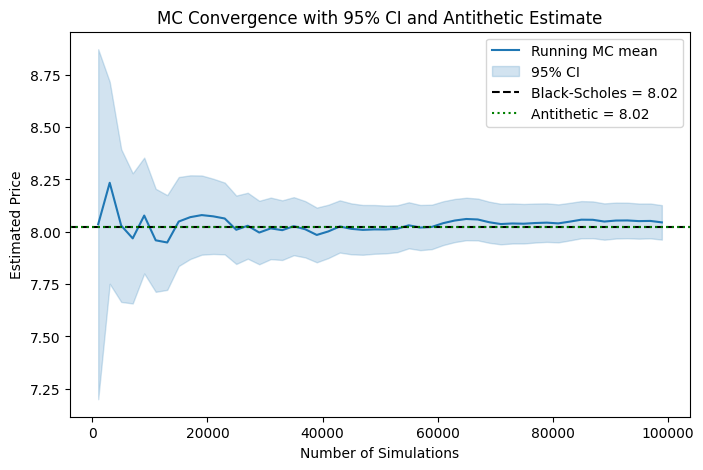

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# assume discounted and sizes are from your simulation above
# discounted = np.exp(-r*T) * payoffs
# sizes = range(1000, n_sims+1, 2000)

means = []
ses = []
for size in sizes:
    chunk = discounted[:size]
    m = np.mean(chunk)
    s = np.std(chunk, ddof=1)
    se = s / np.sqrt(size)
    means.append(m)
    ses.append(se)

means = np.array(means)
ses = np.array(ses)
ci_low = means - 1.96 * ses
ci_high = means + 1.96 * ses

# Antithetic estimate (single-value)
np.random.seed(42)
Z = np.random.standard_normal(n_sims//2)
Z_pair = np.concatenate([Z, -Z])[:n_sims]
ST_ant = S0 * np.exp((r - 0.5 * sigma**2)*T + sigma*np.sqrt(T)*Z_pair)
payoffs_ant = np.maximum(ST_ant - K, 0)
mc_ant_price = np.exp(-r*T) * np.mean(payoffs_ant)

plt.figure(figsize=(8,5))
plt.plot(list(sizes), means, label="Running MC mean")
plt.fill_between(list(sizes), ci_low, ci_high, color='C0', alpha=0.2, label="95% CI")
plt.axhline(bs_price, linestyle='--', color='k', label=f"Black-Scholes = {bs_price:.2f}")
plt.axhline(mc_ant_price, linestyle=':', color='g', label=f"Antithetic = {mc_ant_price:.2f}")
plt.xlabel("Number of Simulations")
plt.ylabel("Estimated Price")
plt.title("MC Convergence with 95% CI and Antithetic Estimate")
plt.legend()
plt.show()


In [14]:
import numpy as np

# Parameters
S0 = 100       # initial price
K = 105        # strike
T = 1          # maturity
r = 0.05       # risk-free rate
sigma = 0.2    # volatility
n_sims = 100000
steps = 252

dt = T/steps
np.random.seed(42)

payoffs = []

for _ in range(n_sims):
    prices = [S0]
    for t in range(steps):
        z = np.random.normal()
        S = prices[-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)
        prices.append(S)
    avg_price = np.mean(prices)
    payoffs.append(max(avg_price - K, 0))

asian_call_price = np.exp(-r*T) * np.mean(payoffs)
print("Asian Call Option Price:", asian_call_price)


Asian Call Option Price: 3.4797975569488955


#Real Data


https://github.com/TheQuantPy/youtube-tutorials/blob/main/2022/001%20Jan-Mar/2022-01-19%20Monte%20Carlo%20Simulation%20for%20Option%20Pricing%20with%20Python%20(Basic%20Ideas%20Explained).ipynb

In [16]:
!pip install yfinance


S0 = 268.03, strike = 125.00, T = 0.0055 years
Vol used (market_iv): 4.4238, r = 0.050, q = 0.3900
Market option lastPrice (per-share): 145.99  (bid 143.00, ask 144.65)
Black-Scholes (per-share) : 142.69
Monte-Carlo (per-share)   : 143.28  95% CI [142.03, 144.53] (n=20000)


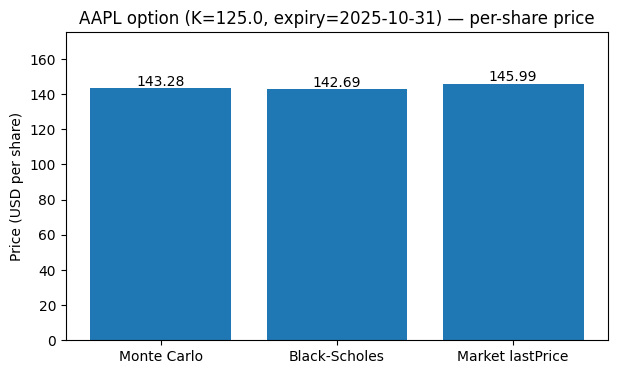


Note: exchange option contracts typically cover 100 shares; multiply per-share price by 100 for per-contract price.


In [25]:


import numpy as np
import pandas as pd
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Parameters / data ---
ticker_sym = "AAPL"
tkr = yf.Ticker(ticker_sym)

# get recent close price (S0)
hist = tkr.history(period="60d", interval="1d")
S0 = float(hist['Close'].iloc[-1])

# pick nearest expiry and call chain row 0 (you can change index)
exp = tkr.options[0]                 # nearest expiry as 'YYYY-MM-DD'
expiry_date = datetime.datetime.strptime(exp, "%Y-%m-%d").date()
today = datetime.date.today()
T = max((expiry_date - today).days, 0) / 365.0

chain = tkr.option_chain(exp)
calls = chain.calls.reset_index(drop=True)
call0 = calls.loc[0]                 # first call in chain

strike = float(call0['strike'])
market_last = float(call0['lastPrice'])   # quoted per-share
market_bid  = float(call0['bid'])
market_ask  = float(call0['ask'])
iv_market   = call0.get('impliedVolatility', np.nan)

# risk-free rate & dividend yield guesses
r = 0.05
q = tkr.info.get('dividendYield', 0.0) or 0.0

# fallback sigma if implied vol missing: use historical vol annualized
if iv_market is None or (isinstance(iv_market, float) and (np.isnan(iv_market) or iv_market<=0)):
    # calculate daily log returns from last 252 trading days if available
    prices = hist['Close'].dropna()
    if len(prices) >= 21:
        logr = np.log(prices / prices.shift(1)).dropna()
        sigma = float(logr.std() * np.sqrt(252))
    else:
        sigma = 0.2
    used_iv_source = "hist_vol"
else:
    sigma = float(iv_market)
    used_iv_source = "market_iv"

# Black-Scholes (European call) with dividend yield q
def bs_call_price(S, K, T, r, q, sigma):
    if T == 0:
        return max(S - K, 0.0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

bs_price = bs_call_price(S0, strike, T, r, q, sigma)

# Monte Carlo (vectorized) for European call (per-share)
n_sims = 20000              # reduce/increase as needed for speed/accuracy
dt = T                      # since we simulate terminal price directly (one-step)
np.random.seed(42)

Z = np.random.standard_normal(n_sims)
ST = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoffs = np.maximum(ST - strike, 0.0)
mc_price = np.exp(-r*T) * np.mean(payoffs)
mc_se = np.exp(-r*T) * np.std(payoffs, ddof=1) / np.sqrt(n_sims)
mc_ci = (mc_price - 1.96*mc_se, mc_price + 1.96*mc_se)

# Print values (per-share)
print(f"S0 = {S0:.2f}, strike = {strike:.2f}, T = {T:.4f} years")
print(f"Vol used ({used_iv_source}): {sigma:.4f}, r = {r:.3f}, q = {q:.4f}")
print(f"Market option lastPrice (per-share): {market_last:.2f}  (bid {market_bid:.2f}, ask {market_ask:.2f})")
print(f"Black-Scholes (per-share) : {bs_price:.2f}")
print(f"Monte-Carlo (per-share)   : {mc_price:.2f}  95% CI [{mc_ci[0]:.2f}, {mc_ci[1]:.2f}] (n={n_sims})")

# Plot comparison (per-share)
labels = ['Monte Carlo', 'Black-Scholes', 'Market lastPrice']
values = [mc_price, bs_price, market_last]

plt.figure(figsize=(7,4))
bars = plt.bar(labels, values)
for bar, v in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.01, f"{v:.2f}", ha='center')
plt.title(f"{ticker_sym} option (K={strike}, expiry={exp}) — per-share price")
plt.ylabel("Price (USD per share)")
plt.ylim(0, max(values)*1.2)
plt.show()

# Note on contract multiplier (if you compare to option contract price)
print("\nNote: exchange option contracts typically cover 100 shares; multiply per-share price by 100 for per-contract price.")
